In [30]:
import scipy

from src.utils import ingaas_processing
import numpy as np
import matplotlib.pyplot as plt

In [31]:
#scan_path = "F://Work//LIPI//scans//scan_20260226_152601.raw"
#scan_path = "C://Users//jeppe//Documents//LIPI//scans//test2//scan_20260226_152601.raw"
scan_path = "C://Users//jeppe//Documents//LIPI//scans//outside//scan_20260319_142551.raw"
cal_path = "data/calibration.npz"
K,P,DIM = ingaas_processing.load_calibration(cal_path)
scan = np.array(ingaas_processing.undistort(ingaas_processing.load_raw_image(scan_path, 640, 512), K, P, DIM))
frame_profile = np.sum(scan, axis=2)

453


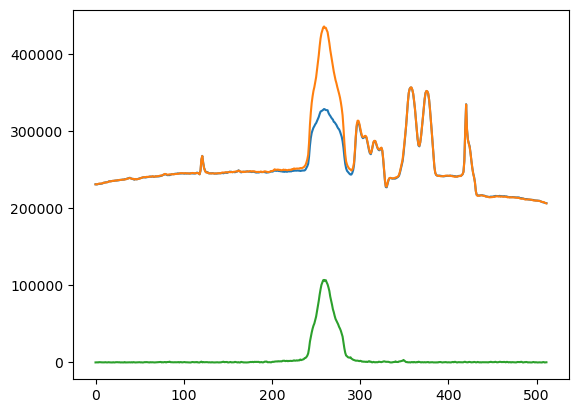

In [32]:
plt.plot(frame_profile[4001])
plt.plot(frame_profile[4000])
plt.plot(np.abs(frame_profile[4001]-frame_profile[4000]))
print(np.argmax(frame_profile[4001]-frame_profile[4000]))

260


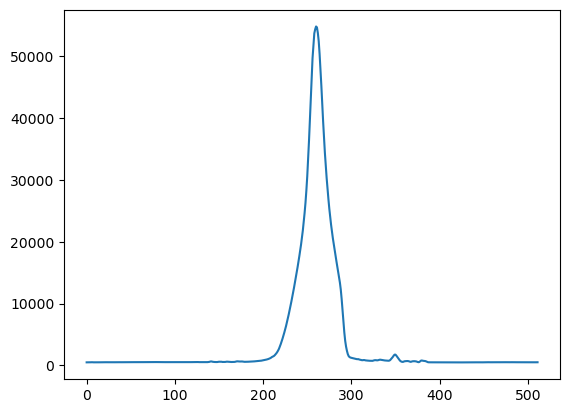

In [34]:
frame_diffs = frame_profile[1:]-frame_profile[:-1]
plt.plot(np.mean(np.abs(frame_diffs), axis=0))
lom = np.argmax(np.mean(np.abs(frame_diffs), axis=0))
print(lom)

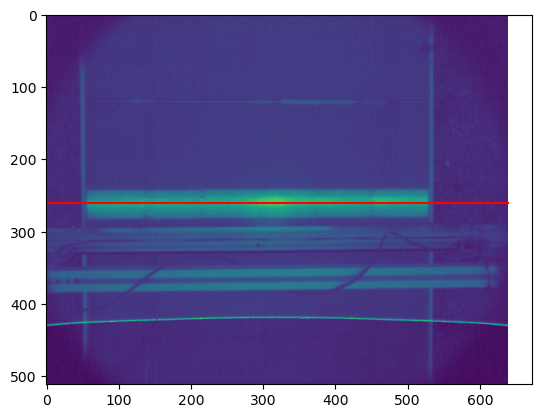

In [36]:
# print(np.min(scan), np.max(scan), scan.shape, scan.dtype)
plt.imshow(scan[4000])
plt.hlines(lom, 0, 640, "r")

In [37]:
scan_profile = frame_profile[:,279]

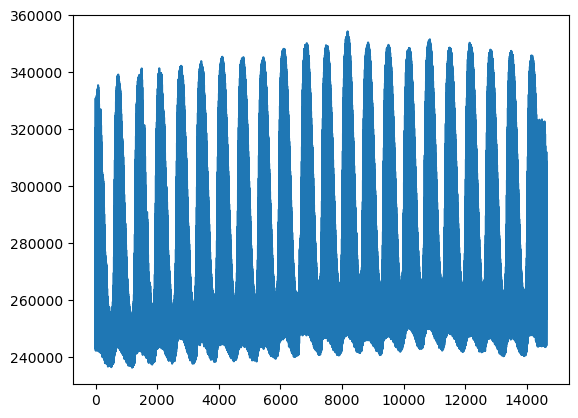

In [38]:
plt.plot(scan_profile)

In [ ]:
# peaks, properties = scipy.signal.find_peaks(scan_profile, prominence=0, wlen=1000)
# sorted_index = np.argsort(properties["prominences"])
# peak_1 = peaks[sorted_index[-1]]
# peak_2 = peaks[sorted_index[-2]]
# print(peak_1, peak_2)
# module_start = min(peak_1, peak_2)
# module_end = max(peak_1, peak_2)
# plt.imshow(scan[module_start])
# plt.show()
# plt.imshow(scan[module_end])
# plt.show()

In [ ]:
# #scipy envelope??
# #low pass filter or something to detect the large peaks then remove start and end of module for further analysis of the scan
#
# coffs = scipy.signal.butter(2, 1/60, output="sos", btype="lowpass")
# print(coffs)
# low_pass = scipy.signal.sosfilt(coffs, scan_profile)
# plt.plot(low_pass)
#
# peaks, properties = scipy.signal.find_peaks(low_pass, width=0, height=0)
# #plt.plot(peaks, scan_profile[peaks], ".")
# #print(properties["peak_heights"])
# sorted_index = np.argsort(properties["peak_heights"])
# module_start = min(peaks[sorted_index[-1]], peaks[sorted_index[-2]])
# module_end = max(peaks[sorted_index[-2]], peaks[sorted_index[-2]])
# #test_width = int(properties["widths"][sorted_index[-1]])
# print(module_start, module_end)
# plt.vlines((module_start, module_end), 0, np.max(low_pass), "r")
# width_end = properties["widths"][sorted_index[-1]]
# width_start = properties["widths"][sorted_index[-2]]
# print(width_start, width_end)
# plt.vlines((module_start+width_start, module_end-width_end), 0, np.max(low_pass), "g")
#
# plt.imshow(scan[int(module_start+width_start)])
# plt.show()
# plt.imshow(scan[int(module_end-width_start)+2])

[0.00000000e+00 3.33424838e-03 6.66849677e-03 ... 1.67196163e-02
 5.38646493e-05 3.38811303e-03]


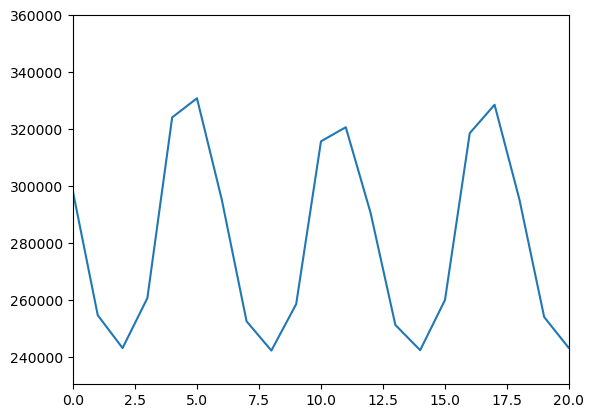

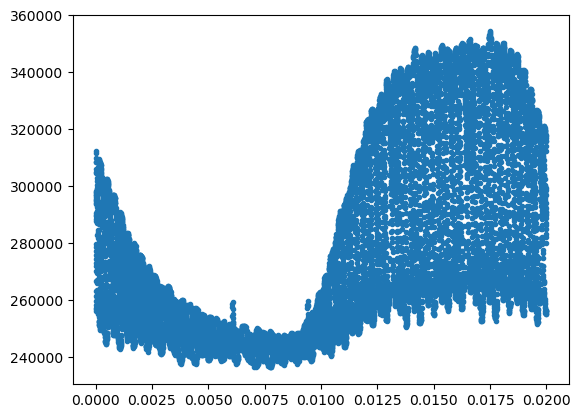

In [39]:
f_m = 50
#f_s = 300
f_s = 299.917668
#print(1/f_m, 6/f_s)
times = (np.arange(scan_profile.shape[0])/f_s) % (1/f_m)
print(times)
sorted_time = np.argsort(times)
#trim_start = module_start+500
trim_start = 0
#trim_end = module_end-500
trim_end = -1
trimmed_profile = scan_profile[trim_start:trim_end]
#plt.plot(trimmed_profile)
#plt.hlines(np.mean(trimmed_profile), 0, 10000, "r")
#binary = np.zeros_like(trimmed_profile)
#binary[trimmed_profile>np.median(trimmed_profile)] = 1
plt.plot(trimmed_profile)
plt.xlim(0, 20)
plt.show()
#to = 18
plt.plot(times[trim_start:trim_end], scan_profile[trim_start:trim_end], ".")

[  19   23   31   33   35   44   47   49   58   61   63   65   90   93
   95   97  101  103  106  108  110  112  114  116  122  125  129  145
  158  161  163  166  170  173  191  194  199  203  206  209  214  225
  227  239  250  252  264  268  286  290  293  295  299  305  308  315
  317  332  357  360  364  367  387  389  392  395  397  401  403  406
  419  431  434  446  449  453  456  458  460  462  477  481  483  486
  488  490  492  494  496  498  501  503  506  538  545  573  576  579
  582  584  586  589  591  594  596  609  623  642  646  649  669  672
  674  676  678  680  684  686  690  695  727  738  740  742  744  769
  771  778  783  785  787  792  795  798  825  827  831  836  838  860
  863  865  867  869  871  875  877  880  882  892  921  927  930  933
  936  939  941  946  964  968  971  975  980  982  985  991  993 1016
 1023 1025 1030 1032 1035 1060 1062 1064 1067 1071 1075 1077 1079 1081
 1085 1096 1107 1114 1116 1120 1125 1127 1152 1154 1156 1161 1163 1167
 1169 

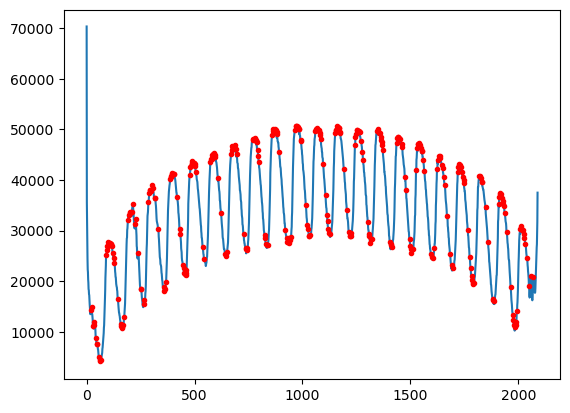

In [41]:
bp_in = (int(50*len(scan_profile)/f_s), None)
scan_env, scan_res = scipy.signal.envelope(scan_profile, bp_in, n_out = int(len(scan_profile)/7))
#plt.plot(scan_profile[trim_start:trim_start+12])
plt.plot(scan_env)
peaks_test, _ = scipy.signal.find_peaks(scan_env)
print(peaks_test)
plt.plot(peaks_test, scan_env[peaks_test], ".r")

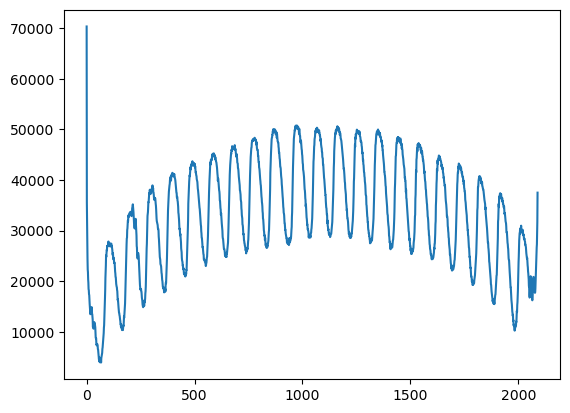

In [45]:
plt.plot(scan_env)
#plt.plot(scan_res)

In [46]:
line_profiles = scan[:, 279, :]
line_env, line_res = scipy.signal.envelope(line_profiles, bp_in, n_out = int(0.3*len(line_profiles)/(int(f_s/f_m))), axis=0)

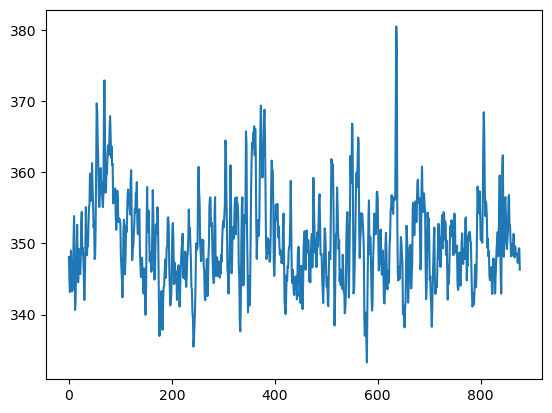

In [47]:
plt.plot(line_res[:,0])

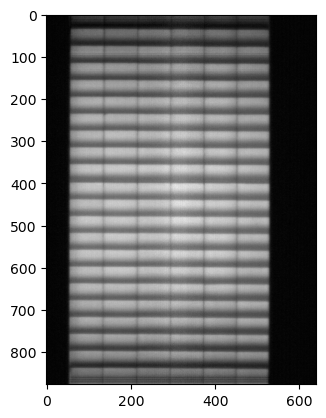

0 255


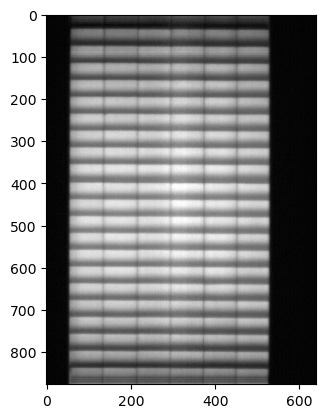

In [50]:
# #Vertical
# v_profile = line_res.sum(axis=1)
# plt.plot(v_profile)
# v_peaks, v_peaks_prop = scipy.signal.find_peaks(v_profile, distance=10, prominence=10000, height=0)
# #print(res_peaks_prop)
# plt.plot(v_peaks, v_profile[v_peaks], ".r")
# plt.show()
# v_peaks_sort = np.argsort(v_peaks_prop["prominences"])
# v_mod_start = min(v_peaks[v_peaks_sort[-1]], v_peaks[v_peaks_sort[-2]])
# v_mod_end = max(v_peaks[v_peaks_sort[-1]], v_peaks[v_peaks_sort[-2]])
#
#
# #Horizontal
# h_profile = line_res.sum(axis=0)
# plt.plot(h_profile)
# h_peaks, h_peaks_prop = scipy.signal.find_peaks(h_profile, distance=10, prominence=70000, height=0)
# plt.plot(h_peaks, h_profile[h_peaks], ".r")
# plt.show()
# h_mod_start = h_peaks[0]
# h_mod_end = h_peaks[-1]

#Final
module = line_res[v_mod_start:v_mod_end, h_mod_start:h_mod_end]
module = line_env
plt.imshow(module, cmap="gray")
plt.show()

#module_process = np.uint16(((module-module.min())/(module.max()-module.min()))*2**16)
module_process = ingaas_processing.lin_stretch_img(module, 0.01, 99.9)
print(module_process.min(), module_process.max())
plt.imshow(module_process, cmap="gray")
plt.show()

In [54]:
test = np.sum(scan, axis=(1,2))

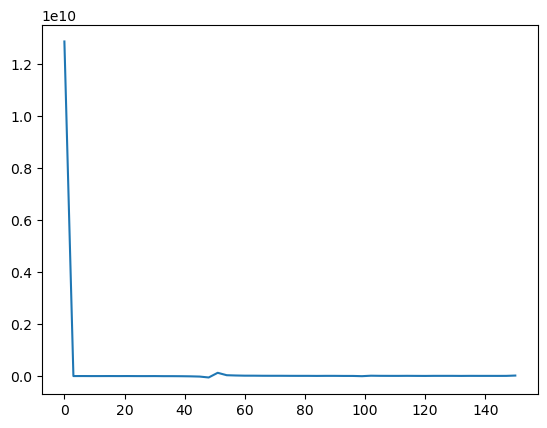

Magnitude: 62533226.9696687 , phase: -2.890990314437079


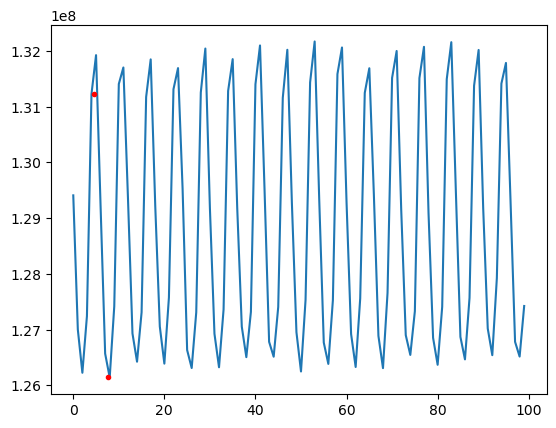

In [83]:
wlen = 100
overlap = 25

test_window = test[0:wlen]

# Where is a 200 Hz frequency in the results?
freq = np.fft.rfftfreq(wlen, d=1/f_s)
index, = np.where(np.isclose(freq, 50, atol=1/(wlen/f_s)))
yf = scipy.fft.rfft(test_window)
plt.plot(freq, yf)
plt.show()

# Get magnitude and phase
magnitude = np.abs(yf[index[0]])
phase = np.angle(yf[index[0]])
print("Magnitude:", magnitude, ", phase:", phase)

peak = -phase+2*np.pi - np.pi/2
valley = -phase+np.pi - np.pi/2
plt.plot(test_window)
plt.plot(peak, test_window[round(peak)], ".r")
plt.plot(valley, test_window[round(valley)], ".r")
